In [22]:
import numpy as np
from iqpy.iqp_to_qiskit import IqpCircuitQiskit
from iqpy.utils import generate_nearest_neighbor_k_local_dataset, generate_single_two_qubit_bitflip_dataset, median_heuristic_fast, generate_experiment_mixture_dataset
from iqpy.ansatzes import fully_connected_IQP_ansatz, nearest_neighbour_IQP_ansatz
from iqpy.torch_training import TrainerTorch
from iqpy.torch_methods import mmd_loss_torch
from qiskit import qpy

n_qubits = 6
gates = fully_connected_IQP_ansatz(n_qubits, max_weight=6)
circuit = IqpCircuitQiskit(n_qubits, gates)

X_train = generate_nearest_neighbor_k_local_dataset(n_qubits=n_qubits, n_samples=1000, k=2, rng=np.random.default_rng(42))

print(f"Training data: {len(X_train)} samples")

sigma = median_heuristic_fast(X_train, n_samples=1000)
print(f"sigma = {sigma:.4f}")

params_init = np.random.normal(0, 1 / np.sqrt(n_qubits), len(gates))

# For a 5-qubit problem with only 32 possible outputs, use ALL binary vectors as ops.
# This gives an exact MMD estimate instead of a stochastic approximation.
all_binary_vecs = np.array(
    [[int(b) for b in format(i, f"0{n_qubits}b")] for i in range(1, 2**n_qubits)],
    dtype=np.float32,
)
ops = all_binary_vecs  # 31 deterministic operators — covers all Fourier modes
n_iqp_samples = 1000

loss_kwargs = {
    "params": params_init,
    "circuit": circuit,
    "ground_truth": X_train,
    "ops": ops,
    "n_samples": n_iqp_samples,
}

trainer = TrainerTorch(mmd_loss_torch, lr=0.01)
trainer.train(n_iters=500, loss_kwargs=loss_kwargs)

final_circuit = circuit.iqp_circuit(trainer.final_params)
final_circuit.measure_all()
with open("circuit.qpy", "wb") as file:
    qpy.dump([final_circuit], file)


Training data: 1000 samples
sigma = 1.4142
Using device: cuda
Step 001 -> Loss: 0.214155
Step 010 -> Loss: 0.122531
Step 020 -> Loss: 0.050623
Step 030 -> Loss: 0.029821
Step 040 -> Loss: 0.016488
Step 050 -> Loss: 0.014241
Step 060 -> Loss: 0.010997
Step 070 -> Loss: 0.010835
Step 080 -> Loss: 0.010790
Step 090 -> Loss: 0.009306
Step 100 -> Loss: 0.009528
Step 110 -> Loss: 0.009051
Step 120 -> Loss: 0.009984
Step 130 -> Loss: 0.007159
Step 140 -> Loss: 0.010951
Step 150 -> Loss: 0.010491
Step 160 -> Loss: 0.009018
Step 170 -> Loss: 0.009059
Step 180 -> Loss: 0.008037
Step 190 -> Loss: 0.008810
Step 200 -> Loss: 0.007036
Step 210 -> Loss: 0.008875
Step 220 -> Loss: 0.006615
Step 230 -> Loss: 0.009990
Step 240 -> Loss: 0.008356
Step 250 -> Loss: 0.010085
Step 260 -> Loss: 0.013294
Step 270 -> Loss: 0.010036
Step 280 -> Loss: 0.007563
Step 290 -> Loss: 0.006796
Step 300 -> Loss: 0.010402
Step 310 -> Loss: 0.010173
Step 320 -> Loss: 0.008722
Step 330 -> Loss: 0.008733
Step 340 -> Loss: 0.

Counts from the original data distribution:


Text(0.5, 1.0, 'Counts from the original data')

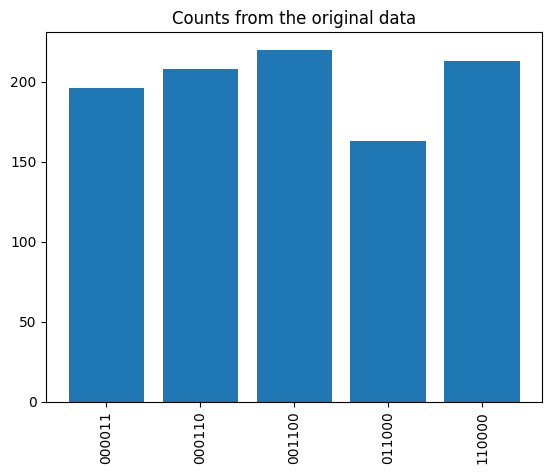

In [23]:
# Plot the counts from the original data distribution
from collections import Counter
X_train = [tuple(x) for x in X_train]
# Convert the list of tuples to a Counter object to get the counts of each unique bitstring
X_train = ["".join(str(bit) for bit in x) for x in X_train]
# Sort the bitstrings for better visualization
X_train.sort()
counts_ideal = Counter(bitstring for bitstring in X_train)
print("Counts from the original data distribution:")
#for bitstring, count in counts_ideal.items():
#    print(f"{bitstring}: {count}")
import matplotlib.pyplot as plt
plt.bar(counts_ideal.keys(), counts_ideal.values())
plt.xticks(rotation=90)
plt.title("Counts from the original data")

Counts from the trained circuit: {'000000': 16, '000001': 28, '000010': 1, '000011': 1566, '000100': 20, '000101': 16, '000110': 1676, '000111': 1, '001000': 2, '001001': 246, '001010': 19, '001011': 13, '001100': 1855, '001101': 2, '001110': 29, '001111': 16, '010000': 20, '010001': 20, '010010': 17, '010100': 14, '010101': 16, '010110': 1, '010111': 204, '011000': 1288, '011001': 2, '011010': 17, '011011': 17, '011100': 2, '011101': 15, '011110': 11, '011111': 13, '100000': 1, '100001': 66, '100010': 13, '100011': 27, '100100': 5, '100110': 18, '100111': 18, '101000': 13, '101001': 20, '101011': 157, '101100': 26, '101101': 19, '101110': 315, '110000': 1717, '110001': 3, '110010': 21, '110011': 19, '110100': 1, '110101': 21, '110110': 22, '110111': 28, '111000': 20, '111001': 17, '111010': 171, '111011': 2, '111100': 18, '111101': 21, '111110': 1, '111111': 57}
Counts from the original data: {'000011': 196, '000110': 208, '001100': 220, '011000': 163, '110000': 213}


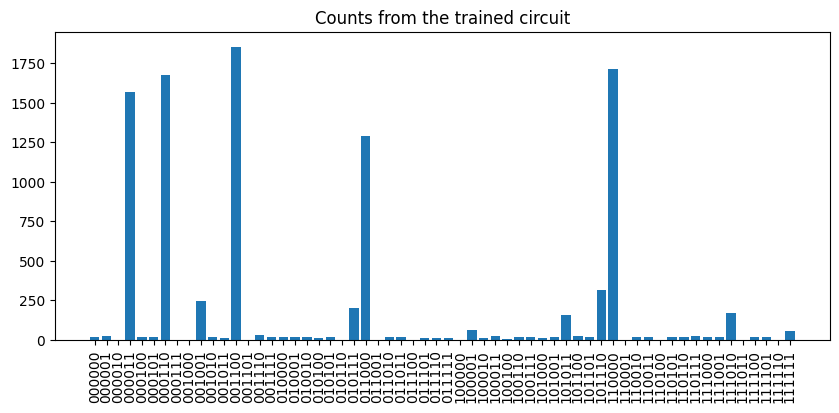

KL(data || circuit) = 0.2107270370773641


In [24]:
# Compare the distribution from the trained circuit with the original data
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer.primitives import SamplerV2
from scipy.stats import entropy

sampler = SamplerV2()
result = sampler.run([final_circuit], shots=10000).result()

raw_circuit_counts = result[0].data.meas.get_counts()

# Qiskit returns bitstrings in reverse order relative to the data arrays.
# Reverse them so both distributions use the same convention.
circuit_counts = Counter({
    bitstring[::-1]: count for bitstring, count in raw_circuit_counts.items()
})
# Sort the circuit counts for better visualization
circuit_counts = Counter(dict(sorted(circuit_counts.items())))

# After Cell 2, X_train is already a list of bitstring strings.
data_counts = Counter(X_train)

print("Counts from the trained circuit:", dict(sorted(circuit_counts.items())))
print("Counts from the original data:", dict(sorted(data_counts.items())))

plt.figure(figsize=(10, 4))
plt.bar(circuit_counts.keys(), circuit_counts.values())
plt.xticks(rotation=90)
plt.title("Counts from the trained circuit")
plt.show()

def counts_to_probs(counts, keys, eps=1e-12):
    probs = np.array([counts.get(k, 0) for k in keys], dtype=float)
    probs = probs + eps
    probs = probs / probs.sum()
    return probs

all_keys = sorted(set(circuit_counts) | set(data_counts))

probs_circuit = counts_to_probs(circuit_counts, all_keys)
probs_data = counts_to_probs(data_counts, all_keys)

kl_divergence = entropy(probs_data, probs_circuit)
print(f"KL(data || circuit) = {kl_divergence}")

In [25]:

# --- Distribution comparison metrics ---
import numpy as np
from scipy.stats import entropy

# The bitstrings the training distribution actually supports
support = set(X_train)
print(f"Support of the training distribution: {support}")

# Build a shared probability distribution over ALL 2^n bitstrings
all_bitstrings = [format(i, f"0{n_qubits}b") for i in range(2**n_qubits)]

def counts_to_full_probs(counts, all_bitstrings, eps=0.0):
    total = sum(counts.values())
    probs = np.array([counts.get(b, 0) / total + eps for b in all_bitstrings], dtype=float)
    probs /= probs.sum()
    return probs

p_data    = counts_to_full_probs(data_counts, all_bitstrings)
p_circuit = counts_to_full_probs(circuit_counts, all_bitstrings)

# Total Variation Distance: TVD = 0.5 * sum |p - q|  (bounded in [0, 1])
tvd = 0.5 * np.sum(np.abs(p_data - p_circuit))

# Hellinger distance: H^2 = 0.5 * sum (sqrt(p) - sqrt(q))^2  (bounded in [0, 1])
hellinger = np.sqrt(0.5 * np.sum((np.sqrt(p_data) - np.sqrt(p_circuit))**2))

# KL divergence with small smoothing to avoid log(0)
eps = 1e-12
p_data_s    = p_data    + eps;  p_data_s    /= p_data_s.sum()
p_circuit_s = p_circuit + eps;  p_circuit_s /= p_circuit_s.sum()
kl = entropy(p_data_s, p_circuit_s)

# Support probability: fraction of circuit samples landing on the 4 correct bitstrings
support_prob = sum(circuit_counts.get(b, 0) for b in support) / sum(circuit_counts.values())

print(f"Total Variation Distance  : {tvd:.4f}  (0 = perfect, 1 = completely wrong)")
print(f"Hellinger Distance        : {hellinger:.4f}  (0 = perfect, 1 = completely wrong)")
print(f"KL(data || circuit)       : {kl:.4f}")
print(f"Support probability       : {support_prob:.4f}  (fraction of samples on the 4 target strings)")
print(f"\nInterpretation: the circuit puts {support_prob*100:.1f}% of its mass on the correct 4 bitstrings.")


Support of the training distribution: {'011000', '000011', '110000', '000110', '001100'}
Total Variation Distance  : 0.1898  (0 = perfect, 1 = completely wrong)
Hellinger Distance        : 0.3161  (0 = perfect, 1 = completely wrong)
KL(data || circuit)       : 0.2107
Support probability       : 0.8102  (fraction of samples on the 4 target strings)

Interpretation: the circuit puts 81.0% of its mass on the correct 4 bitstrings.
